Student Name : Loyana Parajuli


Student  Number : 2414972

# Task 1: Data Understanding and Visualization:

In [3]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/AI/Data/collab/week5/FruitinAmazon.zip'
extract_path = "dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction done!")

Extraction done!


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
train_dir = "dataset/FruitinAmazon/train"

# Check structure
print(os.listdir("dataset"))
print(os.listdir(train_dir))

['FruitinAmazon']
['tucuma', 'pupunha', 'guarana', 'graviola', 'cupuacu', 'acai']


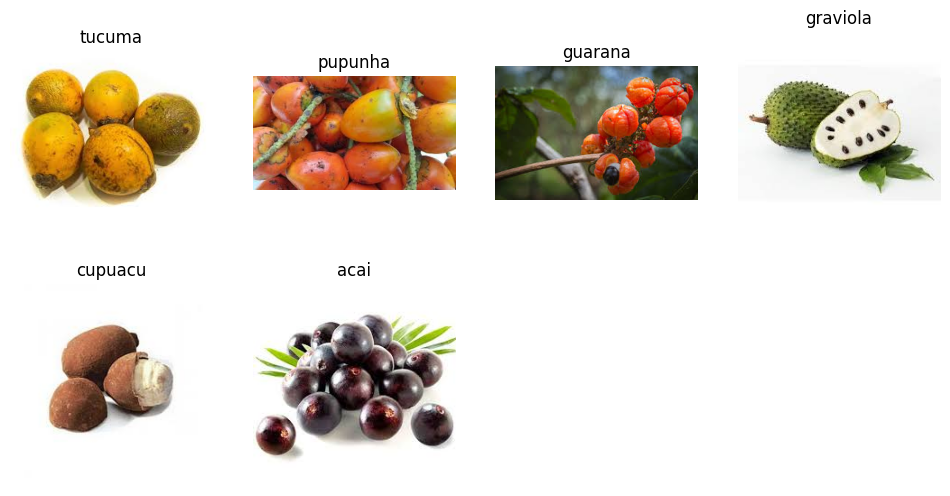

In [5]:
import random
import matplotlib.pyplot as plt
from PIL import Image

classes = os.listdir(train_dir)

plt.figure(figsize=(12,6))

for i, cls in enumerate(classes):
    class_path = os.path.join(train_dir, cls)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)

    plt.subplot(2, (len(classes)//2)+1, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.show()

Check for Corrupted Image

In [6]:
corrupted = []

for cls in os.listdir(train_dir):
    class_path = os.path.join(train_dir, cls)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            img = Image.open(img_path)
            img.verify()
        except:
            corrupted.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if len(corrupted) == 0:
    print("No Corrupted Images Found.")

No Corrupted Images Found.


# Task 2: Loading and Preprocessing Image Data in keras

In [7]:
import tensorflow as tf

img_height = 128
img_width = 128
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
num_classes = len(class_names)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# Normalize
rescale = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

print("Classes:", class_names)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


# Task 3 - Implement a CNN

In [8]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),

    layers.Dense(num_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

# Task 4: Compile the Model

In [9]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

In [10]:
model = models.Sequential([
    data_augmentation,

    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax')
])

In [11]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Task 4: Train the Model

In [12]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint("best_model.h5", monitor='val_accuracy', save_best_only=True)
early_stop = EarlyStopping(patience=10, restore_best_weights=True)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.1690 - loss: 1.9336

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 403ms/step - accuracy: 0.1944 - loss: 2.0144 - val_accuracy: 0.1667 - val_loss: 1.8787
Epoch 2/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.1748 - loss: 1.8949

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 358ms/step - accuracy: 0.1806 - loss: 1.8604 - val_accuracy: 0.2222 - val_loss: 1.8062
Epoch 3/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 298ms/step - accuracy: 0.2222 - loss: 1.7754 - val_accuracy: 0.0556 - val_loss: 1.7954
Epoch 4/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 462ms/step - accuracy: 0.2222 - loss: 1.7775 - val_accuracy: 0.1667 - val_loss: 1.7736
Epoch 5/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.2396 - loss: 1.7747

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 310ms/step - accuracy: 0.2500 - loss: 1.7752 - val_accuracy: 0.2778 - val_loss: 1.7380
Epoch 6/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 316ms/step - accuracy: 0.2222 - loss: 1.7468 - val_accuracy: 0.1667 - val_loss: 1.7421
Epoch 7/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 291ms/step - accuracy: 0.2917 - loss: 1.7003 - val_accuracy: 0.0556 - val_loss: 1.8385
Epoch 8/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 322ms/step - accuracy: 0.2639 - loss: 1.7079 - val_accuracy: 0.1667 - val_loss: 1.7951
Epoch 9/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.2344 - loss: 1.7147

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 352ms/step - accuracy: 0.2500 - loss: 1.6914 - val_accuracy: 0.3333 - val_loss: 1.6580
Epoch 10/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 289ms/step - accuracy: 0.2778 - loss: 1.5804 - val_accuracy: 0.2778 - val_loss: 1.6361
Epoch 11/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 305ms/step - accuracy: 0.2639 - loss: 1.7688 - val_accuracy: 0.1667 - val_loss: 1.7560
Epoch 12/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 292ms/step - accuracy: 0.2222 - loss: 1.7629 - val_accuracy: 0.1667 - val_loss: 1.9021
Epoch 13/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 297ms/step - accuracy: 0.2222 - loss: 1.6905 - val_accuracy: 0.1111 - val_loss: 1.7716
Epoch 14/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 445ms/step - accuracy: 0.2778 - loss: 1.6220 - val_accuracy: 0.2778 - val_loss: 1.7177
Epoch 15/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 396ms/step - accuracy: 0.4028 - loss: 1.5924 - val_accuracy: 0.3333 - val_loss: 1.7061
Epoch 16/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 297ms/step - accuracy: 0.3194 - loss: 1.4970 - val_accuracy: 0.2778 - val_loss: 1.7

# Task 5: Evaluate the Model

In [13]:
loss, acc = model.evaluate(val_ds)
print("Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.2778 - loss: 1.6361
Accuracy: 0.2777777910232544


# Task 6: Save and Load the Model

In [14]:
model.save("final_model.keras")

In [15]:
from tensorflow.keras.models import load_model
loaded_model = load_model("best_model.h5")

# Task 7: Predictions and Classification Report

In [16]:
loss, acc = loaded_model.evaluate(val_ds)
print("Loaded Model Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - accuracy: 0.3333 - loss: 1.6580
Loaded Model Accuracy: 0.3333333432674408


In [17]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
              precision    recall  f1-score   support

        acai       0.50      1.00      0.67         1
     cupuacu       0.00      0.00      0.00         2
    graviola       0.00      0.00      0.00         3
     guarana       0.00      0.00      0.00         5
     pupunha       0.27      1.00      0.42         4
      tucuma       0.00      0.00      0.00         3

    accuracy                           0.28        18
   macro avg       0.13      0.33      0.18        18
weighted avg       0.09      0.28      0.13        18



Keys in history.history: dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


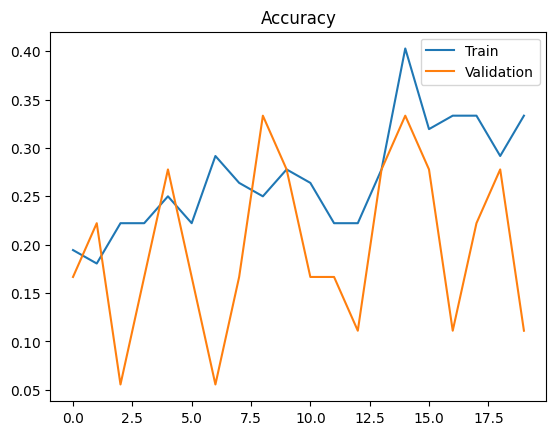

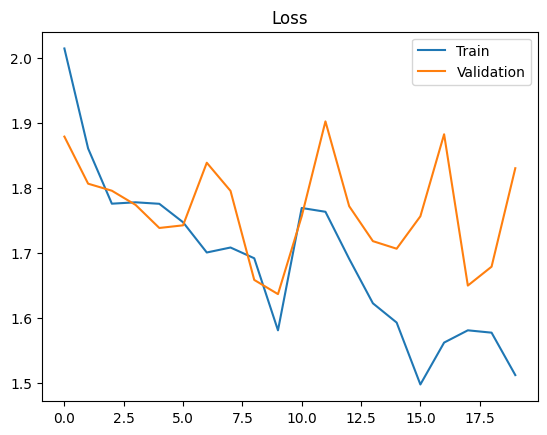

In [18]:
import matplotlib.pyplot as plt

print("Keys in history.history:", history.history.keys())

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

Accuracy: Training accuracy generally increases over time but validation accuracy fluctuates and remains lower  indicating weak generalization.

Loss: Training loss steadily decreases while validation loss is unstable and does not consistently improve suggesting overfitting.

 Classification Report:

In [19]:
import numpy as np
from sklearn.metrics import classification_report

# Collect true labels and predictions
y_true = []
y_pred = []

for images, labels in val_ds:   # use test_ds if you have a separate test set
    preds = loaded_model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

# Print classification report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
Classification Report:

              precision    recall  f1-score   support

        acai       0.20      1.00      0.33         1
     cupuacu       0.00      0.00      0.00         2
    graviola       0.00      0.00      0.00         3
     guarana       0.00      0.00      0.00         5
     pupunha       0.38      0.75      0.50         4
      tucuma       0.40      0.67      0.50         3

    accuracy                           0.33        18
   macro avg       0.16      0.40      0.22        18
weighted avg       0.16      0.33      0.21        18



The model shows low overall accuracy (~28%) with several classes having zero precision and recall indicating poor performance and likely class imbalance. Accuracy can be improved by addressing class imbalance (e.g., class weights), applying stronger data augmentation and tuning hyperparameters. However, the most effective approach would be using transfer learning with a pre-trained model which can improve performance on small datasets and reduce overfitting.